In [54]:
# source ../.venv/bin/activate

# trzeba uruchomic jupyter lab z tego juz dzialajacego srodowiska


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import minimize_scalar


from trgb_lib import *

print("ok")

ok


In [56]:


def fit_alpha_mle(m, m1, m2):
    """
    MLE dla nachylenia RGB luminosity function:

        phi(m) ~ 10**(alpha * (m - m1))

    w zakresie m1 <= m <= m2.

    Zwraca:
        alpha_mle, alpha_err, result
    """

    m = np.asarray(m, dtype=float)

    # wybór gwiazd w zakresie fitu
    mask = (m >= m1) & (m <= m2)
    mm = m[mask]

    N = len(mm)
    if N < 3:
        raise ValueError("Za mało gwiazd w zakresie fitu.")

    W = m2 - m1
    x = mm - m1
    ln10 = math.log(10.0)

    def loglike(alpha):
        """
        log L(alpha)
        """
        if alpha <= 0:
            return -np.inf

        lam = alpha * ln10

        return (
            N * math.log(lam)
            + lam * np.sum(x)
            - N * math.log(math.exp(lam * W) - 1.0)
        )

    def neg_loglike(alpha):
        return -loglike(alpha)

    res = minimize_scalar(
        neg_loglike,
        bounds=(0.001, 2.0),
        method="bounded"
    )

    alpha_mle = res.x

    # analityczna druga pochodna log-likelihood
    lam = alpha_mle * ln10
    E = math.exp(lam * W)

    # d2 lnL / d alpha2
    d2logL = (
        -N / alpha_mle**2
        + N * (ln10**2) * (W**2) * E / (E - 1.0)**2
    )

    alpha_err = math.sqrt(-1.0 / d2logL)

    return alpha_mle, alpha_err, res

# overlaping moving window diagnostics

def local_alpha_ratio(m, d=1.0, step=0.01, mmin=None, mmax=None):

    m = np.asarray(m)

    if mmin is None:
        mmin = m.min() + d
    if mmax is None:
        mmax = m.max() - d

    x = np.arange(mmin, mmax, step)

    alpha = []
    sigma_alpha = []

    for z in x:

        a = np.sum((m > z-d) & (m < z))
        b = np.sum((m > z) & (m < z+d))

        if a > 0 and b > 0:

            alpha_i = np.log10(b/a) / d

            sigma_i = (
                1.0 / (d * np.log(10))
                * np.sqrt(1.0/a + 1.0/b)
            )

        else:
            alpha_i = np.nan
            sigma_i = np.nan

        alpha.append(alpha_i)
        sigma_alpha.append(sigma_i)

    return x, np.array(alpha), np.array(sigma_alpha)

In [57]:
seed = random_seed()

m_trgb = 10.0

m = rgb_lf(m_trgb=m_trgb,alpha=0.3,m_range=3.0,N_1mag=500,seed=seed,)

alpha_mle, alpha_err, res = fit_alpha_mle(m,m1=m_trgb + 0.5,m2=m_trgb + 2.0)

print(f"alpha = {alpha_mle:.4f} ± {alpha_err:.4f}")

x_alpha, alpha_loc, sigma_alpha = local_alpha_ratio(m,d=0.5,step=0.01)


print(f"alpha local = {np.nanmean(alpha_loc):.4f} ± {np.nanstd(alpha_loc):.4f}")

alpha = 0.3195 ± 0.0286
alpha local = 0.3008 ± 0.0483


In [58]:
mask = (
    np.isfinite(alpha_loc)
    & np.isfinite(sigma_alpha)
)

# obserwowany RMS wokół globalnego MLE
R_obs2 = np.mean(
    (alpha_loc[mask] - alpha_mle)**2
)

# oczekiwany wkład szumu Poissona
R_noise2 = np.mean(
    sigma_alpha[mask]**2
)

# nadmiarowa "chropowatość"
R_excess2 = max(0.0, R_obs2 - R_noise2)
R_excess = np.sqrt(R_excess2)

print(f"R_obs    = {np.sqrt(R_obs2):.4f}")
print(f"R_noise  = {np.sqrt(R_noise2):.4f}")
print(f"R_excess = {R_excess:.4f}")

R_obs    = 0.0518
R_noise  = 0.0580
R_excess = 0.0000


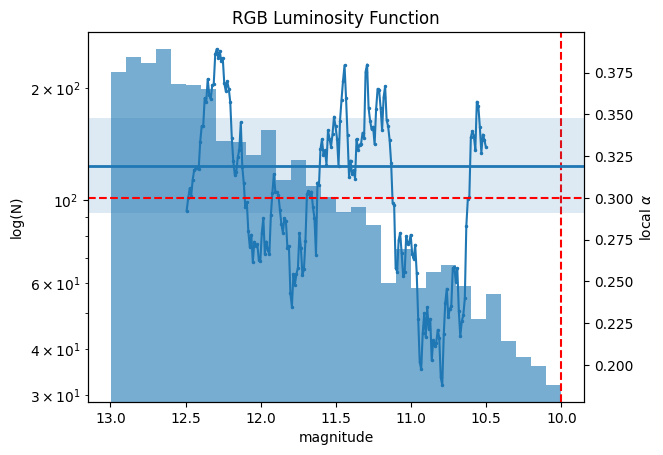

In [59]:


fig, ax1 = plt.subplots()

# ---------- LF ----------
ax1.hist(
    m,
    bins=30,
    histtype='bar',
    alpha=0.6,
    label='LF'
)

ax1.axvline(
    m_trgb,
    color='red',
    linestyle='--',
    label='TRGB'
)

ax1.set_yscale('log')
ax1.invert_xaxis()

ax1.set_xlabel("magnitude")
ax1.set_ylabel("log(N)")


# ---------- local alpha ----------
ax2 = ax1.twinx()

ax2.plot(
    x_alpha,
    alpha_loc,
    '.-',
    markersize=3,
    label=r'local $\alpha$'
)

# prawdziwa wartość z symulacji
ax2.axhline(
    0.3,
    color='red',
    linestyle='--',
    label=r'true $\alpha=0.3$'
)

# wartość MLE
ax2.axhline(
    alpha_mle,
    linestyle='-',
    linewidth=2,
    label=rf'MLE $\alpha={alpha_mle:.3f}\pm{alpha_err:.3f}$'
)

# niepewność MLE
ax2.axhspan(
    alpha_mle - alpha_err,
    alpha_mle + alpha_err,
    alpha=0.15
)

ax2.set_ylabel(r'local $\alpha$')

plt.title("RGB Luminosity Function")
plt.show()

In [60]:
import numpy as np
from scipy.signal import find_peaks, peak_prominences, peak_widths
from scipy.stats import binom, norm

def local_poisson_filter(mags,d=0.5,alpha=0.3,step=0.01,sigma=0.0,method="score",):
    """
    Compute a local Poisson edge response for a luminosity function.

    Two adjacent magnitude intervals are compared at each position z:

        a = N(z - d <= m < z)
        b = N(z <= m < z + d)

    For a smooth luminosity function

        phi(m) proportional to 10**(alpha * m),

    the expected count ratio is

        R = lambda_b / lambda_a = 10**(alpha * d).

    Available methods
    -----------------
    difference
        Raw count excess:

            D = b - R*a

    score
        Signed score statistic for the null hypothesis
        lambda_b = R*lambda_a:

            Z = (b - R*a) / sqrt(R*(a+b))

    lrt
        Signed square root of the Poisson likelihood-ratio statistic.

    Parameters
    ----------
    mags : array_like
        Stellar magnitudes.
    d : float, optional
        Width of each adjacent magnitude interval.
    alpha : float, optional
        Logarithmic luminosity-function slope.
    step : float, optional
        Sampling step of the response function.
    sigma : float, optional
        Gaussian smoothing width applied to the final response.
    method : {'difference', 'score', 'lrt'}, optional
        Statistic returned by the filter.

    Returns
    -------
    x : ndarray
        Magnitudes at which the filter was evaluated.
    response : ndarray
        Filter response.
    counts_bright : ndarray
        Counts in the bright-side intervals.
    counts_faint : ndarray
        Counts in the faint-side intervals.
    """

    mags = np.asarray(mags, dtype=float)
    mags = mags[np.isfinite(mags)]

    if mags.size == 0:
        raise ValueError("mags must contain at least one finite magnitude.")

    if d <= 0:
        raise ValueError("d must be positive.")

    if step <= 0:
        raise ValueError("step must be positive.")

    if sigma < 0:
        raise ValueError("sigma cannot be negative.")

    if method not in {"difference", "score", "lrt"}:
        raise ValueError("method must be 'difference', 'score', or 'lrt'.")

    mags = np.sort(mags)

    mmin = mags[0]
    mmax = mags[-1]

    x = np.arange(mmin + d, mmax - d + 0.5 * step, step)

    if x.size == 0:
        raise ValueError("Magnitude range is too small for the selected d.")

    # searchsorted avoids repeatedly constructing Boolean masks.
    left_1 = np.searchsorted(mags, x - d, side="left")
    left_2 = np.searchsorted(mags, x, side="left")
    right_2 = np.searchsorted(mags, x + d, side="left")

    a = left_2 - left_1
    b = right_2 - left_2

    a = a.astype(float)
    b = b.astype(float)

    ratio = 10.0**(alpha * d)
    excess = b - ratio * a

    if method == "difference":

        response = excess

    elif method == "score":

        variance = ratio * (a + b)

        response = np.zeros_like(excess)

        mask = variance > 0
        response[mask] = (excess[mask] / np.sqrt(variance[mask]))

    elif method == "lrt":

        n = a + b

        mu_a = n / (1.0 + ratio)
        mu_b = ratio * n / (1.0 + ratio)

        deviance = np.zeros_like(excess)

        mask_a = a > 0
        mask_b = b > 0

        deviance[mask_a] += (a[mask_a] * np.log(a[mask_a] / mu_a[mask_a]))

        deviance[mask_b] += (b[mask_b] * np.log(b[mask_b] / mu_b[mask_b]))

        deviance *= 2.0
        deviance = np.maximum(deviance, 0.0)

        response = np.sign(excess) * np.sqrt(deviance)

    elif method == "binomial":

        n = a + b
        p0 = ratio / (1.0 + ratio)

        p_value = np.ones_like(excess, dtype=float)

        valid = n > 0

        p_value[valid] = binom.sf(b[valid] - 1,n[valid],p0,)
        tiny = np.finfo(float).tiny
        p_safe = np.clip(p_value, tiny, 1.0)

        response = norm.isf(p_safe)

    if sigma > 0:

        gx = np.arange(-5.0 * sigma,5.0 * sigma + 0.5 * step,step,)

        kernel = np.exp(-0.5 * (gx / sigma)**2)

        kernel /= np.sum(kernel)

        response = np.convolve(response,kernel,mode="same",)

    return x, response, a, b


def detect_local_peak(x,response,d,initial=None,search_range=None,min_height=None,min_prominence=None,local_fraction=0.7,competitor_fraction=0.5,min_peak_separation=None,):
    """
    Detect the main positive local maximum and measure its quality.

    Parameters
    ----------
    x : array_like
        Coordinates of the filter response.
    response : array_like
        Signed filter response.
    d : float
        Width of one counting window used by the filter. It defines
        the natural local scale around the detected peak.
    initial : float or None, optional
        Approximate expected TRGB magnitude.
    search_range : float or None, optional
        If initial is given, restrict detection to
        initial +/- search_range.
    min_height : float or None, optional
        Minimum accepted peak height.
    min_prominence : float or None, optional
        Minimum accepted peak prominence.
    local_fraction : float, optional
        Minimum peak height relative to the main peak when counting
        local teeth within +/- d.
    competitor_fraction : float, optional
        Minimum relative height of a competing peak.
    min_peak_separation : float or None, optional
        Minimum separation between peaks passed to scipy.find_peaks.
        If None, no explicit separation is imposed.

    Returns
    -------
    trgb : float
        Position of the detected main peak.
    diagnostics : dict
        Peak-quality statistics.
    """

    x = np.asarray(x, dtype=float)
    response = np.asarray(response, dtype=float)

    if x.ndim != 1 or response.ndim != 1:
        raise ValueError("x and response must be one-dimensional.")

    if x.size != response.size:
        raise ValueError("x and response must have the same length.")

    if x.size < 3:
        raise ValueError("At least three response points are required.")

    if d <= 0:
        raise ValueError("d must be positive.")

    if not np.all(np.isfinite(x)):
        raise ValueError("x must contain only finite values.")

    if not np.all(np.isfinite(response)):
        raise ValueError("response must contain only finite values.")

    if not np.all(np.diff(x) > 0):
        raise ValueError("x must be strictly increasing.")

    step = np.median(np.diff(x))

    if min_peak_separation is None:
        distance_samples = None
    else:
        distance_samples = max(1,int(np.round(min_peak_separation / step)),)

    peak_indices, properties = find_peaks(response,height=min_height,prominence=min_prominence,distance=distance_samples,)

    if peak_indices.size == 0:
        raise ValueError("No local maximum satisfies the criteria.")

    # Restrict the candidate list to the requested TRGB region.
    candidate_indices = peak_indices.copy()

    if initial is not None and search_range is not None:
        inside = (np.abs(x[candidate_indices] - initial)<= search_range)
        candidate_indices = candidate_indices[inside]

    if candidate_indices.size == 0:
        raise ValueError("No local maximum found in the selected search range.")

    # The main peak is the highest positive candidate.
    main_index = candidate_indices[np.argmax(response[candidate_indices])]

    main_x = x[main_index]
    main_height = response[main_index]

    prominences, left_bases, right_bases = peak_prominences(response,np.array([main_index]),)

    main_prominence = prominences[0]

    widths, _, left_ips, right_ips = peak_widths(response,np.array([main_index]),rel_height=0.5,prominence_data=(prominences, left_bases, right_bases),)

    width_half_prominence = widths[0] * step

    left_width = (main_index - left_ips[0]) * step
    right_width = (right_ips[0] - main_index) * step

    width_sum = left_width + right_width

    if width_sum > 0:
        width_asymmetry = (right_width - left_width) / width_sum
    else:
        width_asymmetry = np.nan

    # Local curvature.
    if 0 < main_index < response.size - 1:
        curvature = -(response[main_index + 1]- 2.0 * response[main_index]+ response[main_index - 1]) / step**2
    else:
        curvature = np.nan

    if main_height != 0 and np.isfinite(curvature):
        normalized_curvature = curvature * d**2 / main_height
    else:
        normalized_curvature = np.nan

    # All detected peaks and their distances from the main peak.
    other_indices = peak_indices[peak_indices != main_index]
    other_distances = np.abs(x[other_indices] - main_x)

    # Local teeth: peaks within +/- d.
    local_mask = ((other_distances <= d) & (response[other_indices]>= local_fraction * main_height))

    local_indices = other_indices[local_mask]

    n_local_peaks = 1 + local_indices.size

    if local_indices.size > 0:
        local_second_index = local_indices[
            np.argmax(response[local_indices])
        ]
        local_second_height = response[local_second_index]
        local_second_ratio = local_second_height / main_height
        local_second_separation = abs(
            x[local_second_index] - main_x
        )
    else:
        local_second_index = None
        local_second_height = np.nan
        local_second_ratio = 0.0
        local_second_separation = np.nan

    # Independent competitors: peaks farther than d from the main peak.
    competitor_mask = (
        (other_distances > d)
        & (
            response[other_indices]
            >= competitor_fraction * main_height
        )
    )

    competitor_indices = other_indices[competitor_mask]

    n_competing_peaks = competitor_indices.size

    if competitor_indices.size > 0:
        second_index = competitor_indices[
            np.argmax(response[competitor_indices])
        ]

        second_height = response[second_index]
        second_ratio = second_height / main_height
        second_separation = abs(x[second_index] - main_x)
        second_x = x[second_index]
    else:
        second_index = None
        second_height = np.nan
        second_ratio = 0.0
        second_separation = np.nan
        second_x = np.nan

    # A simple sharpness measure. This is diagnostic, not an error.
    if width_half_prominence > 0:
        sharpness = main_prominence / width_half_prominence
    else:
        sharpness = np.nan

    diagnostics = {
        "trgb": main_x,
        "index": int(main_index),

        "peak_height": main_height,
        "peak_prominence": main_prominence,
        "peak_width_half_prominence": width_half_prominence,
        "left_width": left_width,
        "right_width": right_width,
        "width_asymmetry": width_asymmetry,

        "curvature": curvature,
        "normalized_curvature": normalized_curvature,
        "sharpness": sharpness,

        "n_local_peaks": int(n_local_peaks),
        "local_second_height": local_second_height,
        "local_second_ratio": local_second_ratio,
        "local_second_separation": local_second_separation,

        "n_competing_peaks": int(n_competing_peaks),
        "second_peak_x": second_x,
        "second_peak_height": second_height,
        "second_peak_ratio": second_ratio,
        "second_peak_separation": second_separation,

        "d": d,
        "step": step,
    }

    return main_x, diagnostics

In [61]:
# ============================================================
# Simulation parameters
# ============================================================

seed = random_seed()

m_trgb = 10.0

alpha_rgb = 0.30
rgb_range = 3.0
N_rgb_1mag = 500

alpha_agb = 0.20
agb_range = 2.0
N_agb_1mag = 40

photometric_error = 0.05

print(f"Seed = {seed}")

Seed = 1726304861


In [62]:
rgb = rgb_lf(m_trgb=m_trgb,alpha=alpha_rgb,m_range=rgb_range,N_1mag=N_rgb_1mag,seed=seed,)

agb = agb_powerlaw_lf(m_trgb=m_trgb,alpha=alpha_agb,m_range=agb_range,N_agb_1mag=N_agb_1mag,seed=seed + 1,)

m = np.concatenate((rgb, agb))

m = add_photometric_errors(m,errors=photometric_error,seed=seed + 2,)

In [63]:
alpha_mle, alpha_err, res = fit_alpha_mle(m,m1=m_trgb + 0.5,m2=m_trgb + 2.0,)

print(f"alpha MLE = {alpha_mle:.4f} ± {alpha_err:.4f}")
print(f"true alpha = {alpha_rgb:.4f}")
print(f"success = {res.success}")

x_alpha, alpha_loc, sigma_alpha = local_alpha_ratio(m,d=0.5,step=0.01,mmin=m_trgb + 0.5,mmax=m_trgb + 2.0,)

print(f"mean local alpha = {np.nanmean(alpha_loc):.4f}")

print(f"median local alpha = {np.nanmedian(alpha_loc):.4f}")

print(f"std local alpha = {np.nanstd(alpha_loc):.4f}")

alpha MLE = 0.3038 ± 0.0284
true alpha = 0.3000
success = True
mean local alpha = 0.3051
median local alpha = 0.3062
std local alpha = 0.0358


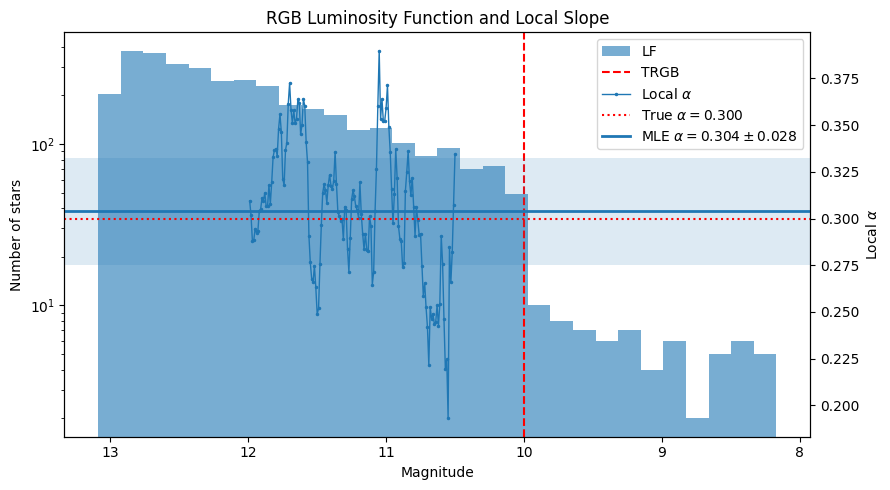

In [64]:
# ============================================================
# Luminosity function and local alpha
# ============================================================

fig, ax1 = plt.subplots(figsize=(9, 5))


# ---------- Luminosity function ----------

ax1.hist(
    m,
    bins=30,
    histtype="bar",
    alpha=0.6,
    label="LF",
)

ax1.axvline(
    m_trgb,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="TRGB",
)

ax1.set_yscale("log")
ax1.invert_xaxis()

ax1.set_xlabel("Magnitude")
ax1.set_ylabel("Number of stars")


# ---------- Local alpha ----------

ax2 = ax1.twinx()

ax2.plot(
    x_alpha,
    alpha_loc,
    ".-",
    markersize=3,
    linewidth=1,
    label=r"Local $\alpha$",
)

# True value used in the simulation
ax2.axhline(
    alpha_rgb,
    color="red",
    linestyle=":",
    linewidth=1.5,
    label=rf"True $\alpha={alpha_rgb:.3f}$",
)

# Global MLE estimate
ax2.axhline(
    alpha_mle,
    linestyle="-",
    linewidth=2,
    label=rf"MLE $\alpha={alpha_mle:.3f}\pm{alpha_err:.3f}$",
)

# MLE uncertainty
ax2.axhspan(
    alpha_mle - alpha_err,
    alpha_mle + alpha_err,
    alpha=0.15,
)

ax2.set_ylabel(r"Local $\alpha$")


# ---------- Combined legend ----------

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="best",
)

ax1.set_title("RGB Luminosity Function and Local Slope")

fig.tight_layout()
plt.show()

In [65]:
# ============================================================
# Local Poisson Edge Detector (LPED)
# ============================================================

# ============================================================
# Local Poisson Edge Detector
# Comparison of four response definitions
# ============================================================

# ============================================================
# Local Poisson Edge Detector
# ============================================================

d = 0.1
step = 0.01

methods = [
    "difference",
    "score",
    "lrt",
]

results = {}

for method in methods:

    x_filter, response, counts_bright, counts_faint = local_poisson_filter(m,d=d,alpha=alpha_mle,step=step,sigma=0.0,method=method,)

    trgb_detected, diagnostics = detect_local_peak(x_filter,response,d=d,initial=m_trgb,search_range=0.5,)

    results[method] = {"x": x_filter,"response": response,"counts_bright": counts_bright,"counts_faint": counts_faint,"trgb": trgb_detected,"diagnostics": diagnostics,}

    print(f"{method:10s}: "f"TRGB = {trgb_detected:.4f}, "f"offset = {trgb_detected - m_trgb:+.4f} mag")
    print()

difference: TRGB = 9.9877, offset = -0.0123 mag

score     : TRGB = 9.9877, offset = -0.0123 mag

lrt       : TRGB = 9.9877, offset = -0.0123 mag



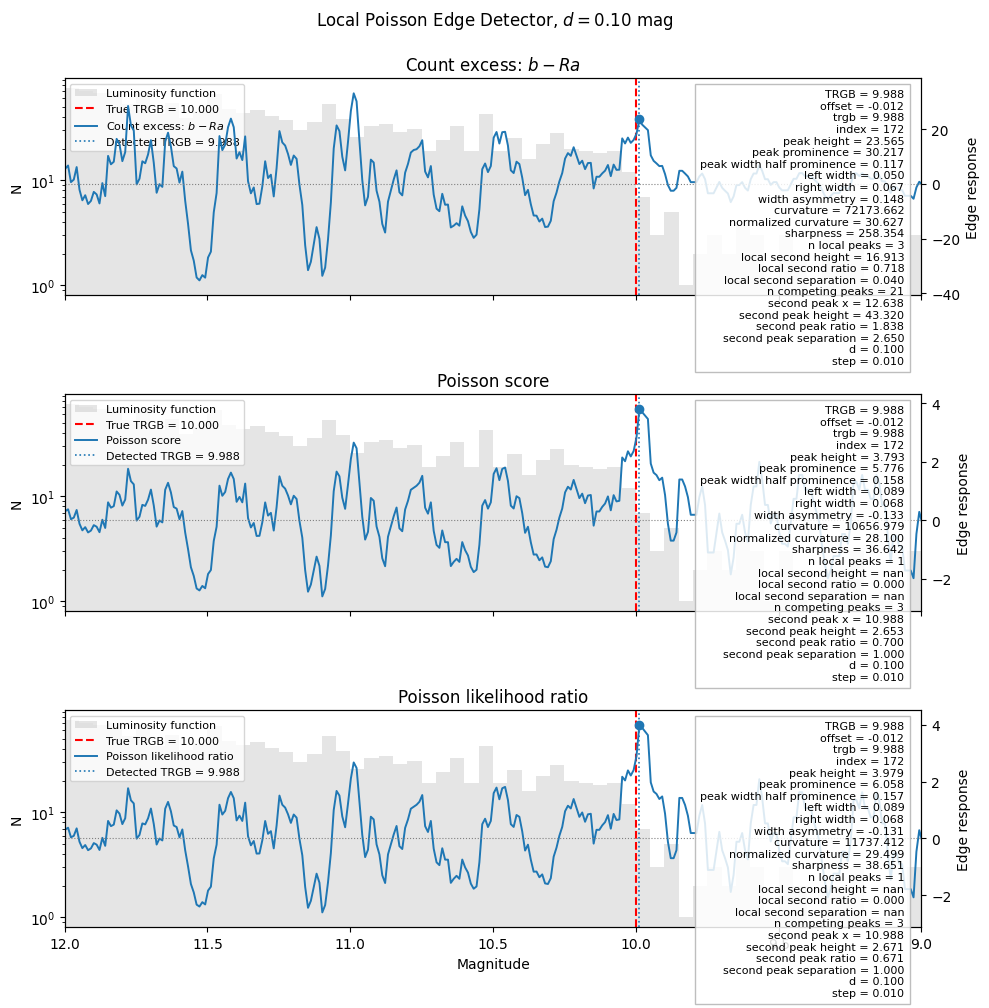

In [66]:


x_bright = 9.0
x_faint = 12.0






# ============================================================
# Helper functions
# ============================================================

def format_diagnostic_value(value):

    if isinstance(value, (bool, np.bool_)):
        return str(bool(value))

    if isinstance(value, (int, np.integer)):
        return str(value)

    if isinstance(value, (float, np.floating)):
        if np.isfinite(value):
            return f"{value:.3f}"
        return str(value)

    return str(value)


def diagnostics_text(result, true_trgb):

    detected_trgb = result["trgb"]
    diagnostics = result["diagnostics"]

    lines = [
        f"TRGB = {detected_trgb:.3f}",
        f"offset = {detected_trgb - true_trgb:+.3f}",
    ]

    for key, value in diagnostics.items():

        # Skip arrays and other non-scalar objects
        if np.ndim(value) != 0:
            continue

        label = key.replace("_", " ")
        value_text = format_diagnostic_value(value)

        lines.append(f"{label} = {value_text}")

    return "\n".join(lines)


def set_visible_ylim(ax, x, y, xmin, xmax, margin_fraction=0.08):

    mask = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x >= xmin)
        & (x <= xmax)
    )

    visible_y = y[mask]

    if visible_y.size == 0:
        return

    ymin = np.min(visible_y)
    ymax = np.max(visible_y)

    yrange = ymax - ymin

    if yrange == 0:
        margin = max(abs(ymax) * margin_fraction, 1.0)
    else:
        margin = margin_fraction * yrange

    ax.set_ylim(
        ymin - margin,
        ymax + margin,
    )


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 10),
    sharex=True,
)

lf_mask = (
    np.isfinite(m)
    & (m >= x_bright)
    & (m <= x_faint)
)

bins = np.arange(
    x_bright,
    x_faint + 0.05,
    0.05,
)


for ax_lf, method in zip(axes, methods):

    result = results[method]

    x_filter = result["x"]
    response = result["response"]
    trgb_detected = result["trgb"]


    # --------------------------------------------------------
    # Luminosity function: left axis
    # --------------------------------------------------------

    ax_lf.hist(
        m[lf_mask],
        bins=bins,
        histtype="bar",
        alpha=0.25,
        color="0.6",
        label="Luminosity function",
    )

    ax_lf.set_yscale("log")
    ax_lf.set_ylabel("N")

    ax_lf.axvline(
        m_trgb,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=rf"True TRGB = {m_trgb:.3f}",
    )


    # --------------------------------------------------------
    # Filter response: right axis
    # --------------------------------------------------------

    ax_response = ax_lf.twinx()

    line, = ax_response.plot(
        x_filter,
        response,
        linewidth=1.4,
        label=labels[method],
    )

    peak_response = np.interp(
        trgb_detected,
        x_filter,
        response,
    )

    ax_response.plot(
        trgb_detected,
        peak_response,
        "o",
        color=line.get_color(),
        markersize=6,
    )

    ax_response.axvline(
        trgb_detected,
        color=line.get_color(),
        linestyle=":",
        linewidth=1.2,
        label=rf"Detected TRGB = {trgb_detected:.3f}",
    )

    ax_response.axhline(
        0.0,
        color="gray",
        linestyle=":",
        linewidth=0.8,
    )

    set_visible_ylim(
        ax_response,
        x_filter,
        response,
        xmin=x_bright,
        xmax=x_faint,
    )

    ax_response.set_ylabel("Edge response")


    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    ax_response.text(
        0.98,
        0.95,
        diagnostics_text(
            result,
            true_trgb=m_trgb,
        ),
        transform=ax_response.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox={
            "facecolor": "white",
            "alpha": 0.85,
            "edgecolor": "0.7",
        },
    )


    # --------------------------------------------------------
    # Combined legend
    # --------------------------------------------------------

    handles_lf, labels_lf = ax_lf.get_legend_handles_labels()
    handles_response, labels_response = (
        ax_response.get_legend_handles_labels()
    )

    ax_lf.legend(
        handles_lf + handles_response,
        labels_lf + labels_response,
        loc="upper left",
        fontsize=8,
    )

    ax_lf.set_title(labels[method])


# ============================================================
# Common formatting
# ============================================================

axes[-1].set_xlim(
    x_faint,
    x_bright,
)

axes[-1].set_xlabel("Magnitude")

fig.suptitle(
    rf"Local Poisson Edge Detector, $d={d:.2f}$ mag",
    y=0.995,
)

fig.tight_layout()
plt.show()

In [67]:

  
#=================== FILTR SOBELA =======================================  
  
def make_sobel(sigma,j,logscale=False):
    numerical_step=0.0005
    m=np.arange(j.min(),j.max()+numerical_step,numerical_step,dtype=float)
    x= (j-j.min())/numerical_step
    indeks = x.astype(int)
    a=np.zeros(len(m))
    for i in indeks:
        a[i]=a[i]+1 
    gauss_x=np.arange(-5*sigma,5*sigma,numerical_step,dtype=float)
    gaussian = lambda x,sigma: 1.*np.exp(-x**2/(2.*sigma**2))
    gauss_y=gaussian(gauss_x,sigma) 
    splot=np.convolve(a,gauss_y,"same")    #to zajmuje mase czasu
    miu=int(0.5*sigma/numerical_step)
    pomocnicza1=splot[2*miu:len(splot)]
    pomocnicza2=splot[0:len(splot)-2*miu]
    maska=pomocnicza1<0.01
    pomocnicza1[maska]=0.01
    maska=pomocnicza2<0.01
    pomocnicza2[maska]=0.01
    sobel_x=m[miu:len(splot)-miu]
    if logscale: 
        sobel=np.log10(pomocnicza1)-np.log10(pomocnicza2)
    else: 
        sobel=pomocnicza1-pomocnicza2
    
    sobel=sobel*splot.max()/sobel.max()
    maska=sobel<0
    sobel[maska]=0
    trim = int((len(sobel) - len(sobel_x))/2.)
    if trim > 0 : 
        sobel=sobel[trim:np.alen(sobel)-trim]
    return m,splot,sobel_x,sobel  
  
  
def sobel_detect(x,sobel,trgb0):
    
    Nmax=max(x)
    trgb=9.
    if trgb0>90 or trgb0==0:
        i=np.argmax(sobel)
        trgb=x[i]
    else:
        x=np.array(x)
        tmp=(x-trgb0)
        tmp=tmp*tmp
        i=np.argmin(tmp)
        k=i
        l=i
        x0=sobel[i]
        zmiana=1
        while zmiana==1 and k+1<len(sobel) and l-1>0:
            if sobel[k] > sobel[k+1] and sobel[k]>sobel[k-1]: 
                zmiana=0
                trgb=x[k]
            elif sobel[l] > sobel[l+1] and sobel[l]>sobel[l-1]: 
                zmiana=0
                trgb=x[l]
            else: 
                zmiana=1   
            k=k+1
            l=l-1
    return trgb      
 

In [68]:
x,l,xf,f = make_sobel(0.03,m,False)
trgb = sobel_detect(x,f,10)
print(trgb)

9.966717365191672


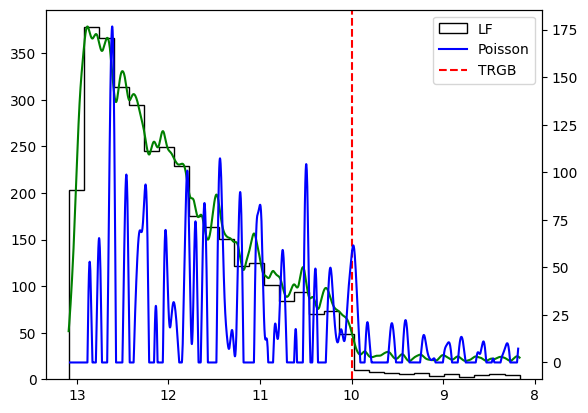

In [69]:
fig, ax1 = plt.subplots()
h = ax1.hist(m, bins=30, histtype='step', color='black', label='LF')

ax2 = ax1.twinx()
l0, = ax2.plot(x, l, '-g', label='Poisson')
l1, = ax2.plot(xf, f, '-b', label='Poisson')
l2 = ax1.axvline(m_trgb, color='red', linestyle='--', label='TRGB')

ax1.invert_xaxis()
handles = [l1, l2]
labels = [h[2][0].get_label(), 'Poisson', 'TRGB']
ax1.legend([h[2][0], l1, l2], labels)

plt.show()

In [70]:

  
#=================== MLA ===========================================
#trgb,a,b,c=mla([10,0.3,1,0.3],0.01,rozklad)  tak jak w pracy Makarov et al. 2006
#sigma_mla to jest rozmycie fi w zwiazku z bledami fot.
#ten pierwszy array to wartosci poczatkowe
#
#x,y=fi_mla(x,trgb,a,b,c,sigma_mla)
#

from scipy.optimize import minimize


def mla(p0,sigma,gtol,rozklad,trgb0):

    res = minimize(
        wiarygodnosc,
        p0,
        args=(rozklad,sigma),
        method='SLSQP',
        bounds=[
            (trgb0-0.5,trgb0+0.5),
            (-1,1),
            (-3,3),
            (-1,1)
        ],
        tol=gtol
    )

    return res.x


def wiarygodnosc(p, r, sigma):

    trgb, a, b, c = p

    _, A = fi_mla(r, trgb, a, b, c, sigma)

    A = np.maximum(A, 1e-300)

    x = np.arange(np.min(r), np.max(r), 0.01)

    _, y = fi_mla(x, trgb, a, b, c, sigma)

    B = np.log(np.sum(y))

    L = -np.sum(np.log(A)) + len(r) * B

    return L


def fi_mla(r, trgb, a, b, c, sigma):

    x = np.arange(np.min(r), np.max(r), 0.01)

    x1 = x[x > trgb]
    y1 = np.exp(np.clip(np.log(10)*(a*(x1-trgb)+b),-700,700))

    x2 = x[x < trgb]
    y2 = np.exp(np.clip(np.log(10)*(c*(x2-trgb)),-700,700))

    xk = np.concatenate((x1, x2))
    yk = np.concatenate((y1, y2))

    idx = np.argsort(xk)

    xk = xk[idx]
    yk = yk[idx]

    if sigma > 0:

        gauss_x = np.arange(-3*sigma, 3*sigma, 0.01)

        gauss_y = np.exp(
            -gauss_x**2/(2*sigma**2)
        )

        gauss_y /= np.sum(gauss_y)

        yk = np.convolve(
            yk,
            gauss_y,
            mode="same"
        )

    y_interp = np.interp(r, xk, yk)

    return r, y_interp
  

TRGB = 10.015404126502645
a = 0.25615353841439287
b = 0.8934419892935334
c = 0.17478635605347576


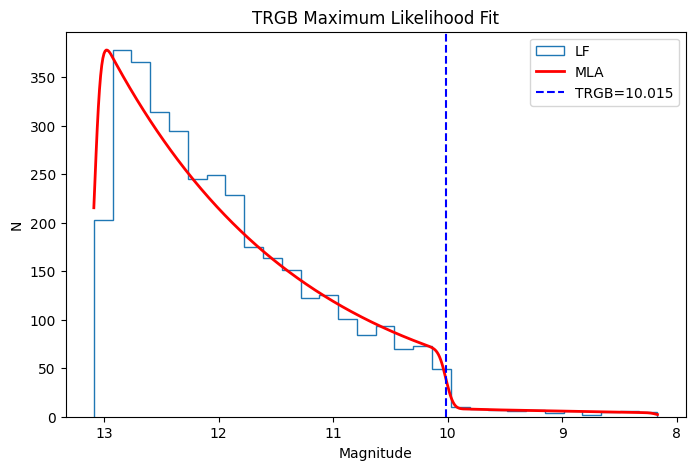

In [71]:
# początkowe zgadywanie
p = mla(
    [10.0,0.3,1,0.3],
    0.05,
    1e-6,
    m,
    trgb0=10.02
)

trgb, a, b, c = p

print("TRGB =", trgb)
print("a =", a)
print("b =", b)
print("c =", c)


# model LF
x_model = np.linspace(
    np.min(m),
    np.max(m),
    500
)

_, y_model = fi_mla(
    x_model,
    trgb,
    a,
    b,
    c,
    0.05
)


plt.figure(figsize=(8,5))

plt.hist(
    m,
    bins=30,
    histtype='step',
    label="LF"
)

# skalowanie modelu
hist_max = np.histogram(m,bins=30)[0].max()

y_model = y_model * hist_max / y_model.max()

plt.plot(
    x_model,
    y_model,
    '-r',
    linewidth=2,
    label="MLA"
)

plt.axvline(
    trgb,
    color='blue',
    linestyle='--',
    label=f"TRGB={trgb:.3f}"
)

plt.gca().invert_xaxis()

plt.xlabel("Magnitude")
plt.ylabel("N")
plt.legend()
plt.title("TRGB Maximum Likelihood Fit")

plt.show()

In [ ]:

def gloess(x, y, sigma):

    """
    Gaussian-windowed locally weighted scatterplot smoothing

    x     - bin centers / magnitudes
    y     - luminosity function
    sigma - smoothing scale (mag)
    """

    y_smooth = np.zeros_like(y, dtype=float)

    for i, xi in enumerate(x):

        # odległość od aktualnego punktu
        dx = x - xi

        # Gaussian weights
        w = np.exp(
            -0.5*(dx/sigma)**2
        )

        # lokalna średnia ważona
        y_smooth[i] = np.sum(w*y) / np.sum(w)

    return y_smooth

def gloess_linear(x,y,sigma):

    ys = np.zeros_like(y,dtype=float)

    for i,xi in enumerate(x):

        dx = x-xi

        w = np.exp(
            -0.5*(dx/sigma)**2
        )


        X = np.vstack(
            [
                np.ones(len(x)),
                dx
            ]
        ).T


        W = np.diag(w)


        beta = np.linalg.solve(
            X.T @ W @ X,
            X.T @ W @ y
        )


        ys[i] = beta[0]


    return ys

def gloess_edge(x,y,sigma):

    smooth = gloess_linear(
        x,y,sigma
    )

    edge = np.gradient(
        smooth,
        x
    )

    return smooth, edge    


In [ ]:
hist, edges = np.histogram(
    m,
    bins=100
)

x = 0.5*(edges[1:]+edges[:-1])
y = hist

smooth, edge = gloess_edge(
    x,
    y,
    sigma=0.05
)


i = np.argmax(edge)

trgb_gloess = sobel_detect(x,edge,10)

print("TRGB GLOESS =", trgb_gloess)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np




fig, ax1 = plt.subplots()

ax2 = ax1.twinx()



# --- LF ---
ax1.step(
    x,
    y,
    where="mid",
    label="LF"
)

ax2.plot(
    x,
    smooth,
    "-r",
    lw=2,
    label="GLOESS"
)

ax2.axvline(
    trgb_gloess,
    color="blue",
    ls="--",
    label=f"TRGB={trgb_gloess:.3f}"
)

ax1.invert_xaxis()
ax1.set_ylabel("N")
ax1.legend()


# --- EDGE ---
ax2.plot(
    x,
    edge,
    "-k",
    lw=2,
    label="d(GLOESS)/dm"
)



plt.tight_layout()
plt.show()

pik musi byc wysoki i samotny

statystyki S1 = max(chi)

R21 = S1 / S2 (1mag)

dm21 = abs(m1-m2)

N_07max_1mag = liczba pikow w jednen mag o wysokosci odpowiednio 0.8max, 0.7max, 0.5max

lokalna dominacja: D = (chi1-chi2)/chi1 = 1 - chi1/chi2

lokalna chropowatosc: Q = liczba maksimow w odleglosci d od centrum.